# DEM (Copernicus GLO-30) – Eindhoven

This notebook prepares static terrain features for the solar radiation project:

- Elevation (m)
- Slope (degrees)
- Aspect (degrees, 0° = North, 90° = East, 180° = South, 270° = West)

What in this notebook:

1. Load Copernicus GLO-30 DEM tiles downloaded from OpenTopography.  
2. Clip them to the Eindhoven region (5–6°E, 51–52°N).  
3. Compute slope and aspect on the native ~30 m grid.  
4. Resample all terrain variables to the SARAH-3 0.05° grid so DEM matches SARAH, CAMS and the monthly Sentinel-2 composites.

Terrain is static so this notebook only needs to be run once for the whole project.

## 1. Imports & basic paths

In [1]:
from pathlib import Path
import tarfile

import numpy as np
import xarray as xr
import rioxarray as rxr
import rasterio
import matplotlib.pyplot as plt

BASE_DIR = Path("data")
DEM_DIR = BASE_DIR / "DEM"
DEM_DIR.mkdir(parents=True, exist_ok=True)

RASTERS_ARCHIVE = DEM_DIR / "rasters_COP30.tar.gz"
VIZ_ARCHIVE     = DEM_DIR / "viz.tar.gz"   # optional, not needed for analysis

print("DEM folder:", DEM_DIR.resolve())
print("Rasters archive exists:", RASTERS_ARCHIVE.exists())

DEM folder: C:\Users\Student\Desktop\SIS\data\DEM
Rasters archive exists: True


## 2. Extract DEM rasters from the OpenTopography archive

In [2]:
RASTERS_OUT = DEM_DIR / "rasters"
RASTERS_OUT.mkdir(exist_ok=True)

if not any(RASTERS_OUT.iterdir()):
    print("📦 Extracting rasters_COP30.tar.gz ...")
    with tarfile.open(RASTERS_ARCHIVE, "r:gz") as tar:
        # Python 3.14 will default to safer extraction; for now this is okay
        tar.extractall(path=RASTERS_OUT)
    print("✅ Extraction done:", RASTERS_OUT)
else:
    print("ℹ Rasters already extracted:", RASTERS_OUT)

dem_files = sorted(RASTERS_OUT.glob("*.tif"))
print(f"\nFound {len(dem_files)} DEM tiles")
for f in dem_files:
    print("  ", f.name)

ℹ Rasters already extracted: data\DEM\rasters

Found 1 DEM tiles
   output_hh.tif


## 3. Inspect one DEM tile

We quickly check:

- CRS – should be WGS84 (EPSG:4326).  
- Resolution – for GLO-30 this is 1 arc-second (~30 m at the equator).  
- Coordinate axes `x` = longitude, `y` = latitude.

In [3]:
sample_dem = rxr.open_rasterio(dem_files[0])
print(sample_dem)
print("CRS:", sample_dem.rio.crs)
print("Resolution (deg):", sample_dem.rio.resolution())

<xarray.DataArray (band: 1, y: 3600, x: 3600)> Size: 52MB
[12960000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 5.0 5.0 5.001 5.001 ... 5.999 5.999 5.999 6.0
  * y            (y) float64 29kB 52.0 52.0 52.0 52.0 ... 51.0 51.0 51.0 51.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
CRS: EPSG:4326
Resolution (deg): (0.0002777777777777778, -0.0002777777777777778)


## 4. Clip DEM to the Eindhoven domain

We keep a simple bounding box:

- Lon: 5.0 – 6.0 °E  
- Lat: 51.0 – 52.0 °N  

In [4]:
# Bounding box in WGS84 (same as SARAH & CAMS)
EHV_BBOX = {
    "min_lon": 5.0,
    "max_lon": 6.0,
    "min_lat": 51.0,
    "max_lat": 52.0,
}

def open_and_reproject(path):
    da = rxr.open_rasterio(path)
    if da.rio.crs is None:
        raise ValueError(f"No CRS found for {path}")
    if da.rio.crs.to_epsg() != 4326:
        da = da.rio.reproject("EPSG:4326")
    return da

dem_list = [open_and_reproject(p) for p in dem_files]

# Merge (if multiple tiles, they would be combined here)
dem_merged = xr.combine_by_coords(dem_list, combine_attrs="drop_conflicts")

# Clip to Eindhoven bbox
dem_ehv = dem_merged.rio.clip_box(
    minx=EHV_BBOX["min_lon"],
    miny=EHV_BBOX["min_lat"],
    maxx=EHV_BBOX["max_lon"],
    maxy=EHV_BBOX["max_lat"],
)

dem_ehv = dem_ehv.squeeze(drop=True)  # remove band dimension
dem_ehv.name = "elevation"

dem_ehv

<xarray.DataArray 'elevation' (y: 3600, x: 3600)> Size: 52MB
[12960000 values with dtype=float32]
Coordinates:
  * x            (x) float64 29kB 5.0 5.0 5.001 5.001 ... 5.999 5.999 5.999 6.0
  * y            (y) float64 29kB 52.0 52.0 52.0 52.0 ... 51.0 51.0 51.0 51.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0

## 5. Elevation map on native GLO-30 grid

This gives a high-resolution view of the topography.

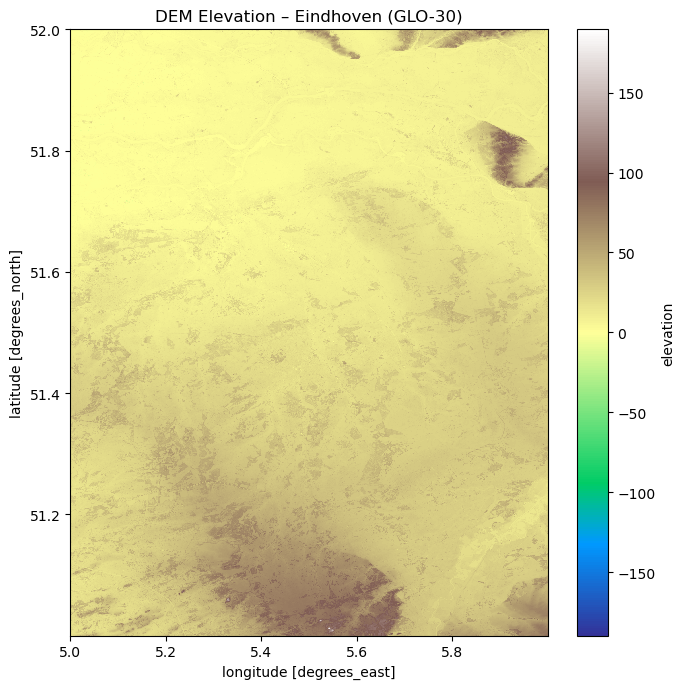

Elevation stats (native grid) [m]:
  min : -20.498798370361328
  max : 189.51467895507812
  mean: 23.663375854492188


In [5]:
plt.figure(figsize=(7, 7))
dem_ehv.plot(cmap="terrain")
plt.title("DEM Elevation – Eindhoven (GLO-30)")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

print("Elevation stats (native grid) [m]:")
print("  min :", float(dem_ehv.min().values))
print("  max :", float(dem_ehv.max().values))
print("  mean:", float(dem_ehv.mean().values))

**Observation:**

- The map shows a mostly yellow, slightly wavy surface → this means the area is generally flat and low.
- The southern edge and a patch in the northeast are darker and a bit brownish – these are the higher hills.
- The city area of Eindhoven itself sits in the light-yellow zone → relatively flat and low-lying.

## 6. Compute slope and aspect on the GLO-30 grid

We approximate slope and aspect using central differences:

- Convert latitude/longitude spacing to metres.
- Use `np.gradient` to compute ∂z/∂x and ∂z/∂y.
- Slope = arctan( √(dzdx² + dzdy²) ).
- Aspect = direction of steepest descent (0° = North, 90° = East, ...).

This level of precision is more than enough for our low-relief Eindhoven domain.

In [6]:
# Convert degrees to metres (approximate, good enough for our ~100 km box)
lat_vals = dem_ehv["y"].values if "y" in dem_ehv.dims else dem_ehv["lat"].values
lon_vals = dem_ehv["x"].values if "x" in dem_ehv.dims else dem_ehv["lon"].values

if "y" in dem_ehv.dims or "x" in dem_ehv.dims:
    z = dem_ehv.values
    y_name, x_name = "y", "x"
else:
    z = dem_ehv.values
    y_name, x_name = "lat", "lon"

dy_deg = np.abs(np.diff(lat_vals).mean())
dx_deg = np.abs(np.diff(lon_vals).mean())
lat_mean_rad = np.deg2rad(lat_vals.mean())

meters_per_deg_lat = 111_320.0
meters_per_deg_lon = meters_per_deg_lat * np.cos(lat_mean_rad)

dy_m = dy_deg * meters_per_deg_lat
dx_m = dx_deg * meters_per_deg_lon

# Gradients in m/m
dz_dy, dz_dx = np.gradient(z, dy_m, dx_m)

slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.rad2deg(slope_rad)

# Aspect: 0° = North, 90° = East, etc.
aspect_rad = np.arctan2(-dz_dx, dz_dy)
aspect_deg = np.rad2deg(aspect_rad)
aspect_deg = (aspect_deg + 360) % 360  # [0, 360)

# Wrap back into DataArrays with the same coords
coords = {x_name: dem_ehv[x_name], y_name: dem_ehv[y_name]}

slope_da = xr.DataArray(
    slope_deg,
    coords=coords,
    dims=(y_name, x_name),
    name="slope",
    attrs={"units": "degrees", "description": "Slope angle from horizontal"},
)

aspect_da = xr.DataArray(
    aspect_deg,
    coords=coords,
    dims=(y_name, x_name),
    name="aspect",
    attrs={"units": "degrees", "description": "Aspect (0°=N, 90°=E)"},
)

slope_da, aspect_da

(<xarray.DataArray 'slope' (y: 3600, x: 3600)> Size: 52MB
 array([[2.556141  , 1.7537562 , 1.4394056 , ..., 1.0679053 , 1.1795157 ,
         0.17398325],
        [2.258429  , 1.1155523 , 1.0476142 , ..., 0.623167  , 0.41078576,
         1.4570886 ],
        [1.7032312 , 0.8829192 , 0.78400016, ..., 1.249398  , 0.51855654,
         0.5617387 ],
        ...,
        [2.5562053 , 1.6507025 , 1.3112715 , ..., 0.45218337, 0.48290053,
         0.76189655],
        [3.6602585 , 1.9082177 , 2.7838316 , ..., 0.27015406, 0.12431221,
         0.6864993 ],
        [2.8025212 , 2.8069167 , 3.0001414 , ..., 0.24408816, 0.5259022 ,
         0.6291816 ]], dtype=float32)
 Coordinates:
   * x        (x) float64 29kB 5.0 5.0 5.001 5.001 ... 5.999 5.999 5.999 6.0
   * y        (y) float64 29kB 52.0 52.0 52.0 52.0 52.0 ... 51.0 51.0 51.0 51.0
 Attributes:
     units:        degrees
     description:  Slope angle from horizontal,
 <xarray.DataArray 'aspect' (y: 3600, x: 3600)> Size: 52MB
 array([[ 52.52643 

### Visualise slope & aspect (native grid)

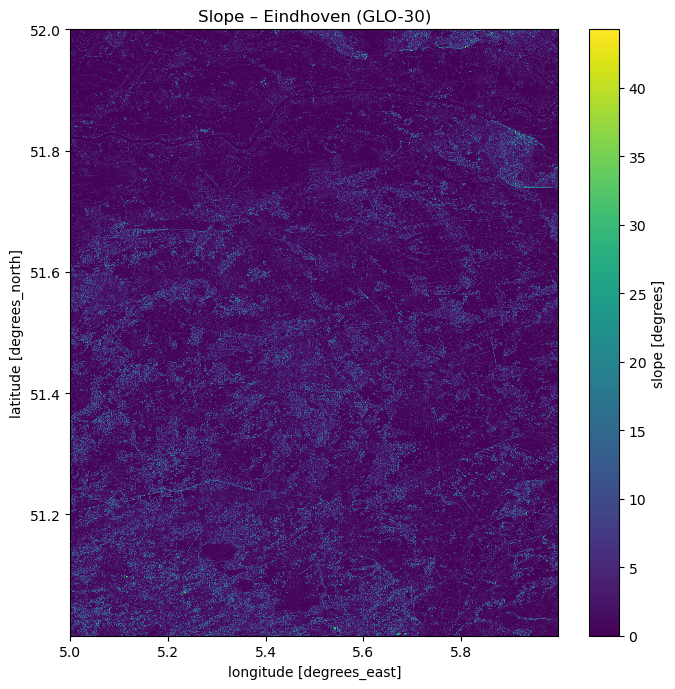

In [14]:
plt.figure(figsize=(7, 7))
slope_da.plot(cmap="viridis")
plt.title("Slope – Eindhoven (GLO-30)")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

**Observation:**
- Most of the map is dark (near 0° slope) → extremely gentle terrain.
- Brighter speckles and lines (higher slope) appear towards the south (hills), in the northeast and
along some river/road embankments and sand dunes.

=> On average, Eindhoven is almost flat, which matches reality. The few steeper places show where terrain could slightly increase or decrease solar gain compared to a flat surface. For a coarse radiation model (5 km cells), these slopes will mainly influence the average tilt of each cell rather than create strong mountain shading.

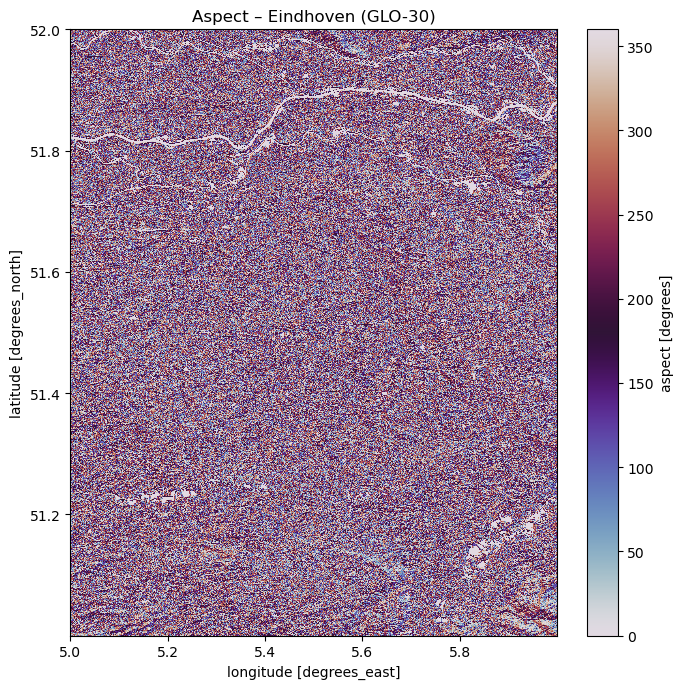

In [17]:

plt.figure(figsize=(7, 7))
aspect_da.plot(cmap="twilight")
plt.title("Aspect – Eindhoven (GLO-30)")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

**Observations**

- The map looks like colourful “noise” at first glance. This is normal: In very flat terrain, even tiny bumps can have a “direction”, so aspect jumps around a lot.
- White/bright lines and shapes highlight places with more consistent aspect, e.g. ridges or edges.

=> Aspect is still useful, but in such flat regions it should be seen as a local micro-direction rather than a strong, dominant slope direction like in mountains. This supports the idea that aspect will have a subtle effect on solar radiation at regional scale.

## 7. Match DEM to the SARAH-3 0.05° grid

SARAH-3 uses a regular 0.05° lat/lon grid over our Eindhoven box.
We will:

1. Open the merged SARAH-3 SIS file.  
2. Take one time slice as a template grid.  
3. Reproject elevation, slope and aspect to that template using
   `rioxarray.reproject_match`.

All three outputs will then have exactly the same shape and coordinates as SARAH,
CAMS (after processing) and our Sentinel-2 monthly composites.

### 7.1 Open SARAH and extract template grid

In [9]:
SARAH_MERGED_FILE = BASE_DIR / "SARAH3" / "sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc"
sarah_ds = xr.open_dataset(SARAH_MERGED_FILE)

template = sarah_ds.isel(time=0)["SIS"]
print(template)

<xarray.DataArray 'SIS' (lat: 20, lon: 20)> Size: 2kB
[400 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2024-01-01
  * lon      (lon) float32 80B 5.025 5.075 5.125 5.175 ... 5.875 5.925 5.975
  * lat      (lat) float32 80B 51.03 51.08 51.12 51.17 ... 51.88 51.92 51.97
Attributes:
    standard_name:        surface_downwelling_shortwave_flux_in_air
    long_name:            Daily mean Surface Downwelling Shortwave Radiation
    units:                W m-2
    ancillary_variables:  SISC
    cell_methods:         time: mean


### 7.2 Prepare DEM/slope/aspect for rioxarray reprojection

In [10]:
# Ensure dims are called 'lat' and 'lon'
if "y" in dem_ehv.dims or "x" in dem_ehv.dims:
    dem_ehv = dem_ehv.rename({"y": "lat", "x": "lon"})
    slope_da = slope_da.rename({"y": "lat", "x": "lon"})
    aspect_da = aspect_da.rename({"y": "lat", "x": "lon"})

dem_ehv = dem_ehv.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
dem_ehv = dem_ehv.rio.write_crs("EPSG:4326", inplace=True)

slope_da = slope_da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
slope_da = slope_da.rio.write_crs("EPSG:4326", inplace=True)

aspect_da = aspect_da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
aspect_da = aspect_da.rio.write_crs("EPSG:4326", inplace=True)

# Prepare SARAH template
template_rio = template.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
template_rio = template_rio.rio.write_crs("EPSG:4326", inplace=False)

print("DEM CRS:", dem_ehv.rio.crs)
print("SARAH template CRS:", template_rio.rio.crs)


DEM CRS: EPSG:4326
SARAH template CRS: EPSG:4326


### 7.3 Resample to SARAH grid

In [11]:
dem_on_sarah    = dem_ehv.rio.reproject_match(template_rio)
slope_on_sarah  = slope_da.rio.reproject_match(template_rio)
aspect_on_sarah = aspect_da.rio.reproject_match(template_rio)

dem_on_sarah.name    = "elevation"
slope_on_sarah.name  = "slope"
aspect_on_sarah.name = "aspect"

dem_on_sarah, slope_on_sarah, aspect_on_sarah


(<xarray.DataArray 'elevation' (y: 20, x: 20)> Size: 2kB
 array([[ 1.89173660e+01,  2.02410240e+01,  2.76804771e+01,
          2.84400597e+01,  2.85852261e+01,  3.38053665e+01,
          5.61631546e+01,  5.32189713e+01,  7.15681000e+01,
          7.66708832e+01,  1.63987625e+02,  9.53599701e+01,
          8.50041351e+01,  9.27027435e+01,  3.44109383e+01,
          2.65000000e+01,  3.54071121e+01,  4.11127472e+01,
          4.61896935e+01,  5.56789742e+01],
        [ 1.62214241e+01,  2.72282219e+01,  2.35992088e+01,
          2.50000000e+01,  3.69888458e+01,  4.22392273e+01,
          7.68028870e+01,  6.81693954e+01,  7.31615829e+01,
          7.38610916e+01,  8.13261108e+01,  7.57694244e+01,
          8.46660690e+01,  6.17737846e+01,  3.18405972e+01,
          2.94437561e+01,  2.99019947e+01,  2.97899723e+01,
          3.45816269e+01,  5.42863770e+01],
        [ 1.81821899e+01,  2.67121925e+01,  3.04410191e+01,
          3.10867996e+01,  4.48420563e+01,  5.28924828e+01,
          5.763

### 7.4 Visual check: DEM on SARAH grid

Now we see the same elevation information but aggregated to 0.05° (~5 km)
cells. Each pixel more or less represents the average terrain in that SARAH cell.

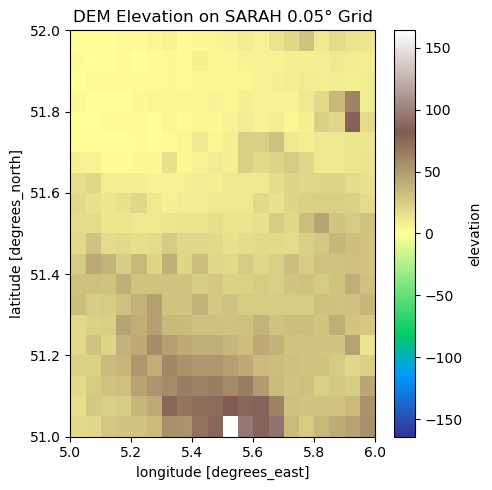

Elevation stats on SARAH grid [m]:
  min : -0.6505405306816101
  max : 163.9876251220703
  mean: 23.350658416748047


In [12]:
plt.figure(figsize=(5, 5))
dem_on_sarah.plot(cmap="terrain")
plt.title("DEM Elevation on SARAH 0.05° Grid")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

print("Elevation stats on SARAH grid [m]:")
print("  min :", float(dem_on_sarah.min().values))
print("  max :", float(dem_on_sarah.max().values))
print("  mean:", float(dem_on_sarah.mean().values))

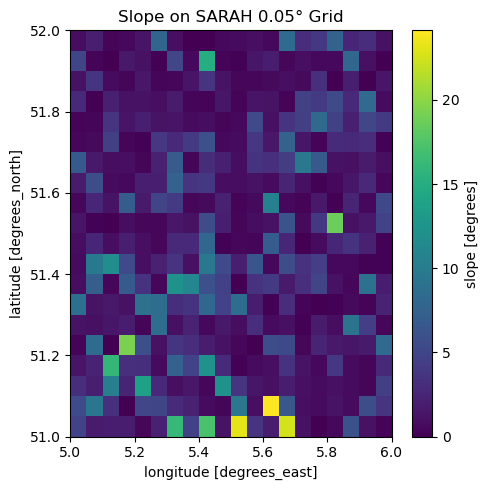

In [18]:
plt.figure(figsize=(5, 5))
slope_on_sarah.plot(cmap="viridis")
plt.title("Slope on SARAH 0.05° Grid")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

**Observation:**

- Most SARAH cells have small slopes (dark colours).
- Some cells in the south and north-east have higher slope values (brighter pixels), capturing the hillier areas in a coarse way.
- Compared to the native slope map, the extremes are smoothed but the “hillier zone vs flat zone” contrast remains.

=> The coarse slope provides a single “typical tilt” per SARAH cell, which can be used to adjust incoming solar radiation in models. We lose rooftop-level detail but gain a simple, consistent terrain feature that can be joined with any time step from SARAH/CAMS.

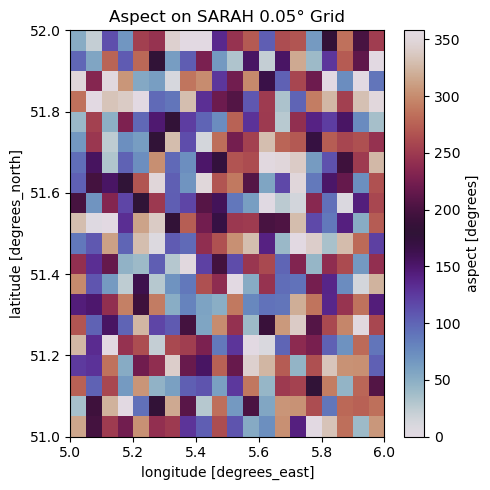

In [19]:

plt.figure(figsize=(5, 5))
aspect_on_sarah.plot(cmap="twilight")
plt.title("Aspect on SARAH 0.05° Grid")
plt.xlabel("longitude [degrees_east]")
plt.ylabel("latitude [degrees_north]")
plt.tight_layout()
plt.show()

**Observation:**

- The map is a patchwork of colours, each cell showing a dominant aspect direction.
- This looks more “blocky” than before because each cell now averages many small aspects.
- Some areas show clusters with similar colours (similar mean aspect); others are more mixed.

=> At this scale, aspect is basically “what is the main tilt direction of the terrain inside this 5 km cell?”. For radiation modelling:
- It can help approximate whether the average terrain is slightly south-facing or north-facing.
- But it should not be interpreted as exact shading information; it’s a coarse correction factor.

## 8. Save DEM, slope and aspect for later use

We save the three SARAH-aligned layers as a small NetCDF file that other notebooks
(SARAH/CAMS/S2 fusion, model training, etc.) can load directly.

In [20]:
DEM_SARAH_OUT = DEM_DIR / "dem_slope_aspect_on_sarah_0.05_ehv.nc"

terrain_ds = xr.Dataset(
    {
        "elevation": dem_on_sarah,
        "slope": slope_on_sarah,
        "aspect": aspect_on_sarah,
    }
)

terrain_ds.to_netcdf(DEM_SARAH_OUT)
print("✅ Saved terrain dataset to:", DEM_SARAH_OUT.resolve())


✅ Saved terrain dataset to: C:\Users\Student\Desktop\SIS\data\DEM\dem_slope_aspect_on_sarah_0.05_ehv.nc


## 9. Conclusion

This notebook prepares static terrain information for the Eindhoven region so it can be used together with SARAH-3 solar radiation, CAMS atmospheric variables and Sentinel-2 composites. Starting from the Copernicus GLO-30 DEM tiles from OpenTopography, we first extracted and inspected the raw raster to confirm its coordinate system (EPSG:4326), resolution (~30 m) and coverage over our 5–6°E, 51–52°N study area. The clipped DEM shows realistic elevation values, roughly from slightly below sea level up to about 180–190 m, with Eindhoven itself sitting in a mostly flat, low-lying zone and some higher terrain toward the south and northeast.

On this native 30 m grid we then derived two additional terrain layers: slope (steepness in degrees) and aspect (dominant downhill direction in degrees, where 0° = north and 180° = south). The slope map confirms that the area is almost everywhere gently sloping, with only a few local patches of higher slope along hills or ridges. The aspect map looks noisy at fine scale, which is normal in flat landscapes where even tiny bumps have a direction. Finally, we regridded elevation, slope and aspect to the SARAH-3 0.05° grid so all three variables now share the same 20×20 (lat, lon) layout as SARAH, CAMS (after regridding) and our Sentinel-2 monthly products. The resulting NetCDF file `dem_slope_aspect_on_sarah_0.05_ehv.nc` provides a compact set of static terrain features that can be loaded directly in later notebooks for feature engineering, model training and interpretation, without having to repeat any DEM processing.